# Análisis de Contenido en plataforma Netflix: Enfoque en Tendencias de la década de los 90s

**By:** Oscar Gamaliel Sandoval Robles
**Objetivo:** Análisis de distribución de contenido y filtro de producciones de acción de corta duración con fines de optimización de catálogo.

<>:27: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
<>:27: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
C:\Users\omicr\AppData\Local\Temp\ipykernel_18544\3134289610.py:27: SyntaxWarning: "\d" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\d"? A raw string is also an option.
  df_movies["duration_num"]= df_movies["duration"].str.extract('(\d+)').astype(float)
C:\Users\omicr\AppData\Local\Temp\ipykernel_18544\3134289610.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="type", data=df, palette="viridis")


Resumen estadístico de años de lanzamiento:
count    8807.000000
mean     2014.180198
std         8.819312
min      1925.000000
25%      2013.000000
50%      2017.000000
75%      2019.000000
max      2021.000000
Name: release_year, dtype: float64


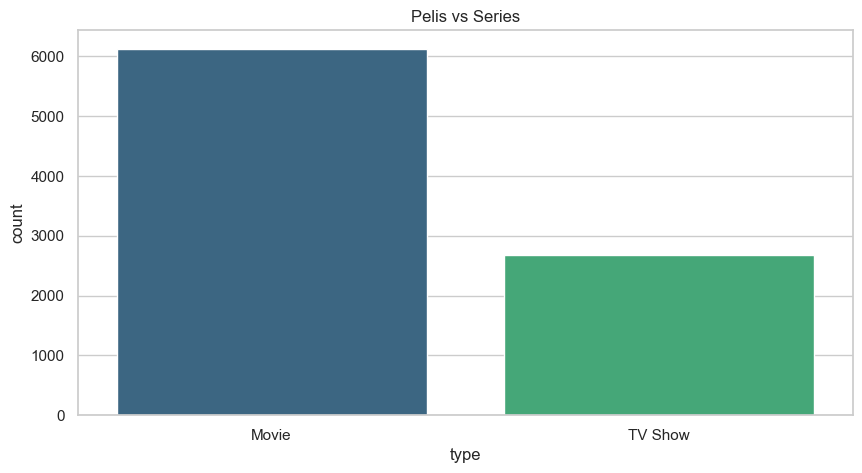


Se encontraron 10 películas de acción de los 90s con duración menor a 90 minuto, de las cuales destacan:


,title,release_year,duration,country
1140,Universal Soldier: The Return,1999,83 min,United States
1353,Beverly Hills Ninja,1997,89 min,United States
3720,EVANGELION: DEATH (TRUE)²,1998,69 min,Japan
3728,The End of Evangelion,1997,87 min,Japan
6962,Hero,1997,89 min,"Hong Kong, China"


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#seleccionamos el estilo de las gráficas:
sns.set_theme(style="whitegrid")

#cargamos los datos como un dataframe:
df = pd.read_csv("netflix_titles.csv")
#cambiamos los nulos de la columna "country" por "Unknown"
df["country"]=df["country"].fillna("Unknown")

#vamos a realizar un análisis rápido:
print("Resumen estadístico de años de lanzamiento:")
print(df["release_year"].describe())

#veamos una comparativa de pelis contra series:
plt.figure(figsize=(10,5))
sns.countplot(x="type", data=df, palette="viridis")
plt.title("Pelis vs Series")
plt.show()

#vamos a aplicar un filtro para ver qué tenemos en los 90

# de las peliculas, convertimos la duración en entero
df_movies=df[df["type"]=="Movie"].copy()
df_movies["duration_num"]= df_movies["duration"].str.extract('(\d+)').astype(float)

#nos enfocamos en los 90's
#nos enfocamos en pelis de acción
#nos enfocamos en las que duren menos de 90 min
filtro_90s=df_movies[
    (df_movies["release_year"].between(1990,1999)) &
    (df_movies["listed_in"].str.contains("Action", case=False)) &
    (df_movies["duration_num"] < 90)
]

#veamos el resultado
print(f"\nSe encontraron {len(filtro_90s)} películas de acción de los 90s con duración menor a 90 minuto, de las cuales destacan:")
display(filtro_90s[['title', 'release_year', 'duration', 'country']].head())




Hay un claro sesgo hacia las producciones más "modernas", pero aún así se conserva un corto catálogo con películas de acción con duración corta en la décaca de los "noventas". 

Existían muchos valores nulos en la columna "country", lo que parece indicar que no es necesario este registro o no es prioritario al momento de llenar la base de datos.

Fin.
